<a href="https://colab.research.google.com/github/Kem1a/OCT-AND-EYE-FUNDUS-DATASET/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip "/content/drive/MyDrive/OCT2017 (2).zip" -d OCT_data


Streaming output truncated to the last 5000 lines.
  inflating: OCT_data/OCT2017/train/DME/DME-778975-42.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-43.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-44.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-45.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-46.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-47.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-48.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-49.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-5.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-50.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-51.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-52.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-53.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-54.jpeg  
  inflating: OCT_data/OCT2017/train/DME/DME-778975-55.jpeg  
  inflating: OCT_data/OCT2017/train

In [ ]:
data_dir = "/content/OCT_data/OCT2017"


⚡ ممتاز! تم اكتشاف الـ GPU وهو جاهز للعمل: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📦 جاري تحميل وقراءة الفئات المحددة...
Found 8906 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 484 images belonging to 2 classes.

🏗️ جاري بناء النموذج وضبط الطبقات الطبية...

🚀 بدء عملية التدريب الحقيقية...
Epoch 1/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 153s 497ms/step - accuracy: 0.6530 - loss: 0.7402 - val_accuracy: 0.5625 - val_loss: 0.6352 - learning_rate: 1.0000e-05
Epoch 2/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 129s 464ms/step - accuracy: 0.7225 - loss: 0.6170 - val_accuracy: 0.8125 - val_loss: 0.4606 - learning_rate: 1.0000e-05
Epoch 3/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 129s 464ms/step - accuracy: 0.7423 - loss: 0.5696 - val_accuracy: 0.8750 - val_loss: 0.2784 - learning_rate: 1.0000e-05
Epoch 4/25
279/279 ━━━━━━━━━━━━━━━━━━━━ 131s 466ms/step - accuracy: 0.7530 - loss: 0.5373 - val_accuracy: 1.0000 - val_loss: 0.1922 - learning_rate: 1.0000e-05
Epoch 5/25

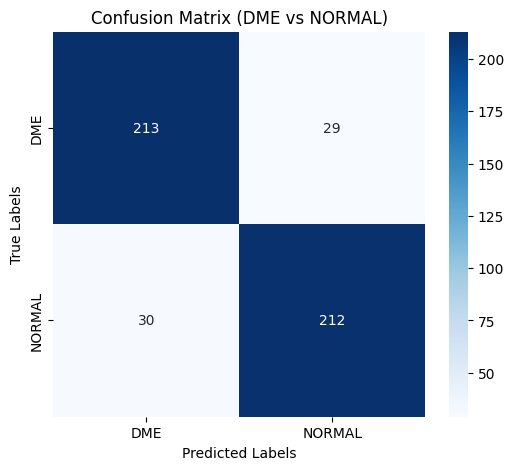


📌 Classification Report:

              precision    recall  f1-score   support

         DME       0.88      0.88      0.88       242
      NORMAL       0.88      0.88      0.88       242

    accuracy                           0.88       484
   macro avg       0.88      0.88      0.88       484
weighted avg       0.88      0.88      0.88       484



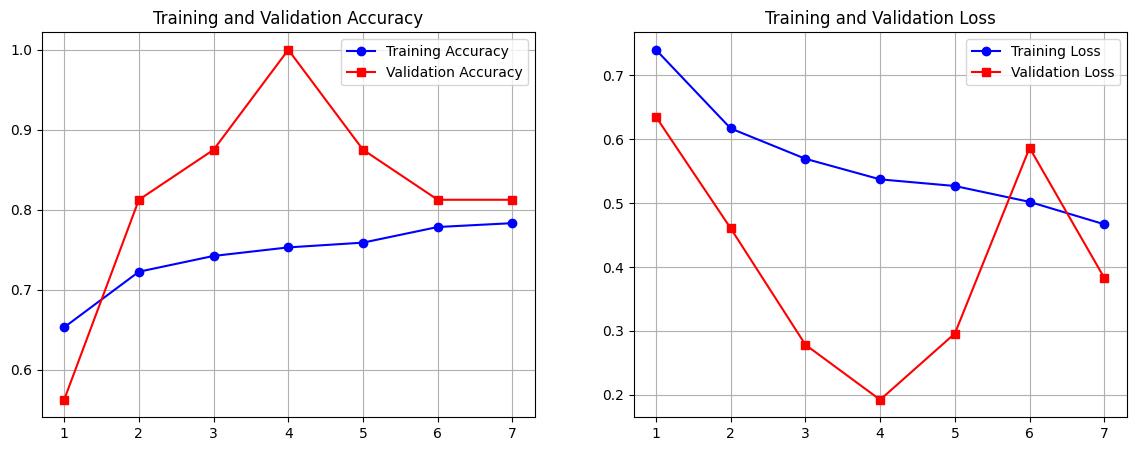

In [ ]:
#RESNET50 QWK 75
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

# فحص أمان للتأكد من وجود الـ GPU قبل استهلاك الوقت
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("⚠️ تحذير: الـ GPU غير مفعّل حالياً! التدريب سيكون بطيئاً جداً. يرجى تفعيله من إعدادات Runtime.")
else:
    print(f"⚡ ممتاز! تم اكتشاف الـ GPU وهو جاهز للعمل: {gpus}")

# ==========================================
# 1) إعداد المسارات والبيانات
# ==========================================
BASE_DIR = "/content/OCT_data/OCT2017"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
TARGET_CLASSES = ['DME', 'NORMAL']

# ==========================================
# 2) تهيئة الـ DataLoader
# ==========================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\n📦 جاري تحميل وقراءة الفئات المحددة...")

train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "val"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=TARGET_CLASSES
)

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

# ==========================================
# 3) بناء النموذج مع الـ Fine-Tuning
# ==========================================
print("\n🏗️ جاري بناء النموذج وضبط الطبقات الطبية...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# تجميد جزئي ليتناسب النموذج مع تفاصيل الأشعة الطبية
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

# رأس التصنيف المطور
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4) أدوات التحكم (Callbacks)
# ==========================================
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("best_oct_expert_model.keras", monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)

callbacks_list = [early_stopping, model_checkpoint, reduce_lr]

# ==========================================
# 5) تشغيل التدريب
# ==========================================
print("\n🚀 بدء عملية التدريب الحقيقية...")
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=callbacks_list
)

print(f"\n⏱️ إجمالي وقت التدريب: {(time.time()-start)/60:.2f} minute(s)")
# ==========================================
# 6) التقييم النهائي ومصفوفة الارتباك
# ==========================================
print("\n📊 جاري التقييم النهائي...")
pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.title("Confusion Matrix (DME vs NORMAL)")
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

print("\n📌 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# ==========================================
# 7) منحنيات الأداء
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r-s', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r-s', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import cohen_kappa_score

qwk = cohen_kappa_score(true_classes, pred_classes, weights='quadratic')
print("QWK Score:", qwk)


QWK Score: 0.756198347107438


⚡ GPU جاهز: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 7126 images belonging to 2 classes.
Found 1780 images belonging to 2 classes.
Found 484 images belonging to 2 classes.

🏗️ بناء النموذج المصحَّح...

🚀 بدء التدريب المصحَّح...
Epoch 1/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 170s 693ms/step - accuracy: 0.6399 - loss: 0.8276 - val_accuracy: 0.5006 - val_loss: 0.8661 - learning_rate: 1.0000e-05
Epoch 2/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 141s 632ms/step - accuracy: 0.7095 - loss: 0.6508 - val_accuracy: 0.6433 - val_loss: 0.6210 - learning_rate: 1.0000e-05
Epoch 3/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 141s 633ms/step - accuracy: 0.7313 - loss: 0.6083 - val_accuracy: 0.6820 - val_loss: 0.7240 - learning_rate: 1.0000e-05
Epoch 4/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 155s 696ms/step - accuracy: 0.7463 - loss: 0.5705 - val_accuracy: 0.7230 - val_loss: 0.6006 - learning_rate: 1.0000e-05
Epoch 5/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 144s 644ms/step - accuracy: 0.7710 - loss: 0.5101 - val_accu

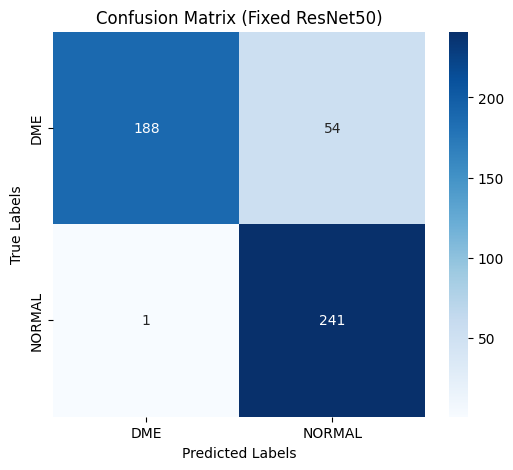


📌 Classification Report:

              precision    recall  f1-score   support

         DME       0.99      0.78      0.87       242
      NORMAL       0.82      1.00      0.90       242

    accuracy                           0.89       484
   macro avg       0.91      0.89      0.88       484
weighted avg       0.91      0.89      0.88       484


🔥 QWK Score: 0.7727272727272727


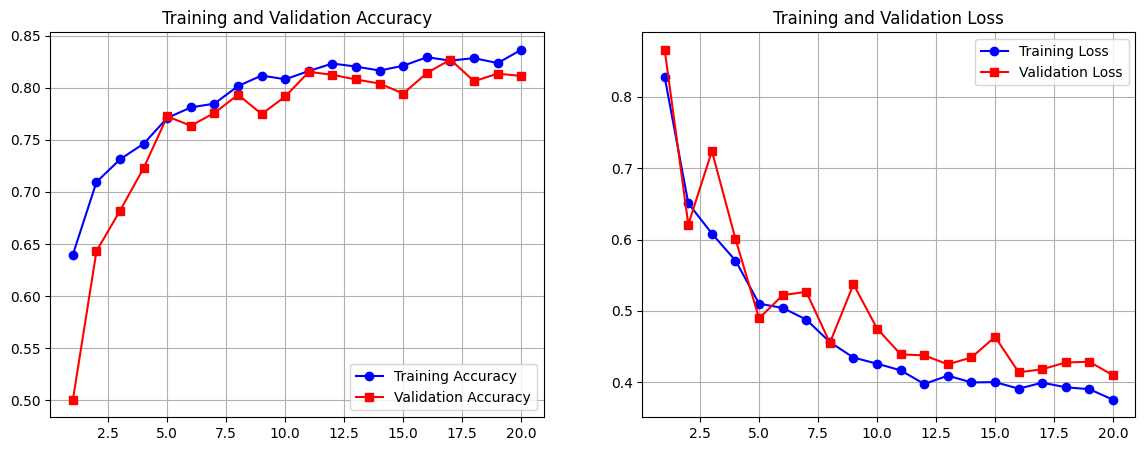

In [ ]:
#RESNET50 QWK 77
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# فحص الـ GPU
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("⚠️ GPU غير مفعّل!")
else:
    print(f"⚡ GPU جاهز: {gpus}")

# ==========================================
# 1) إعداد المسارات
# ==========================================
BASE_DIR = "/content/OCT_data/OCT2017"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
TARGET_CLASSES = ['DME', 'NORMAL']

# ==========================================
# 2) DataLoader مع validation_split ثابت
# ==========================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1]  # تخفيف التغيير في الإضاءة
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=TARGET_CLASSES
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=TARGET_CLASSES
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=TARGET_CLASSES
)

class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

# ==========================================
# 3) بناء النموذج + Fine‑Tuning متوسط
# ==========================================
print("\n🏗️ بناء النموذج المصحَّح...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# فتح آخر 20 طبقة فقط
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

optimizer = Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 4) Callbacks مستقرة
# ==========================================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_oct_resnet50_fixed.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-7
)

callbacks_list = [early_stopping, model_checkpoint, reduce_lr]

# ==========================================
# 5) التدريب
# ==========================================
print("\n🚀 بدء التدريب المصحَّح...")
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks_list
)

print(f"\n⏱️ وقت التدريب: {(time.time()-start)/60:.2f} دقيقة")

# ==========================================
# 6) التقييم + QWK
# ==========================================
print("\n📊 التقييم النهائي...")

pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.title("Confusion Matrix (Fixed ResNet50)")
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

print("\n📌 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

qwk = cohen_kappa_score(true_classes, pred_classes, weights='quadratic')
print(f"\n🔥 QWK Score: {qwk}")

# ==========================================
# 7) منحنيات الأداء
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r-s', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r-s', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.legend()
plt.show()


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 7126 images belonging to 2 classes.
Found 1780 images belonging to 2 classes.
Found 484 images belonging to 2 classes.
Classes: ['DME', 'NORMAL']

🚀 بدء تدريب Stage‑1 فقط (10 Epochs)...
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.8056 - loss: 0.4265 - val_accuracy: 0.8843 - val_loss: 0.2814 - learning_rate: 2.0000e-05
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9171 - loss: 0.2068 - val_accuracy: 0.9157 - val_loss: 0.2149 - learning_rate: 2.0000e-05
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9376 - loss: 0.1590 - val_accuracy: 0.9185 - val_loss: 0.2191 - learning_rate: 2.0000e-05
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9477 - loss: 0.1381 - val_accuracy: 0.9157 - val_loss: 0.2428 - learning_rate: 2.0000e-05
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9524 - loss: 0.1210 - val_accuracy: 0.916

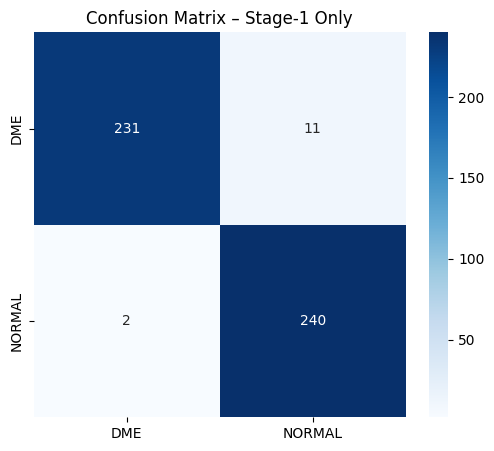


📌 Classification Report:

              precision    recall  f1-score   support

         DME       0.99      0.95      0.97       242
      NORMAL       0.96      0.99      0.97       242

    accuracy                           0.97       484
   macro avg       0.97      0.97      0.97       484
weighted avg       0.97      0.97      0.97       484


🔥 QWK Score: 0.9463


In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# فحص الـ GPU
gpus = tf.config.list_physical_devices('GPU')
print("GPU:", gpus)

# ============================
# 1) إعداد البيانات
# ============================
BASE_DIR = "/content/OCT_data/OCT2017"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
TARGET_CLASSES = ['DME', 'NORMAL']

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.85, 1.15]
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    classes=TARGET_CLASSES
)

val_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "train"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    classes=TARGET_CLASSES
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, "test"),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=TARGET_CLASSES
)

class_labels = list(train_generator.class_indices.keys())
print("Classes:", class_labels)

# ============================
# 2) بناء النموذج – Stage 1 فقط
# ============================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# فتح آخر 20 طبقة فقط
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ============================
# 3) Stage‑1 Callbacks
# ============================
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7)
checkpoint = ModelCheckpoint("best_stage1_model.keras", monitor='val_loss', save_best_only=True)

# ============================
# 4) تدريب Stage‑1 فقط (10 Epochs)
# ============================
print("\n🚀 بدء تدريب Stage‑1 فقط (10 Epochs)...")
start = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

print(f"\n⏱️ وقت التدريب: {(time.time()-start)/60:.2f} دقيقة")

# ============================
# 5) التقييم النهائي
# ============================
print("\n📊 تقييم النموذج على test...")

pred_probs = np.squeeze(model.predict(test_generator))
pred_classes = (pred_probs > 0.5).astype(int)
true_classes = np.array(test_generator.classes)

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap="Blues")
plt.title("Confusion Matrix – Stage‑1 Only")
plt.show()

print("\n📌 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

qwk = cohen_kappa_score(true_classes, pred_classes, weights='quadratic')
print(f"\n🔥 QWK Score: {qwk:.4f}")


In [ ]:
import os

print(len(os.listdir("/content/OCT_data/OCT2017/train/DME")))
print(len(os.listdir("/content/OCT_data/OCT2017/test/DME")))


4458
243
